# 1. Import Libraries

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from arch import arch_model

# 2. Download Bitcoin Data
Downloading historical Bitcoin prices from Yahoo Finance.

In [17]:
ticker = "BTC-USD"

data = yf.download(
    ticker,
    start="2021-01-01",
    end="2026-09-01",
    interval="1d",
    auto_adjust=True,
    progress=False
)

price = data["Close"]

if isinstance(price, pd.DataFrame):
    price = price.iloc[:, 0]

df = pd.DataFrame({
    "price": price
})

df.dropna(inplace=True)

df.head()

,price
Date,
2021-01-01,29374.152344
2021-01-02,32127.267578
2021-01-03,32782.023438
2021-01-04,31971.914062
2021-01-05,33992.429688


# 3. Calculate Log Returns
Transforming prices into logarithmic returns for financial time series analysis.

In [18]:
df["log_return"] = np.log(df["price"] / df["price"].shift(1))

returns = df["log_return"].dropna() * 100

df.head()

,price,log_return
Date,,
2021-01-01,29374.152344,NaN
2021-01-02,32127.267578,0.089590
2021-01-03,32782.023438,0.020175
2021-01-04,31971.914062,-0.025022
2021-01-05,33992.429688,0.061280


# 4. Bitcoin Price Visualization
Visualizing the historical Bitcoin price series.

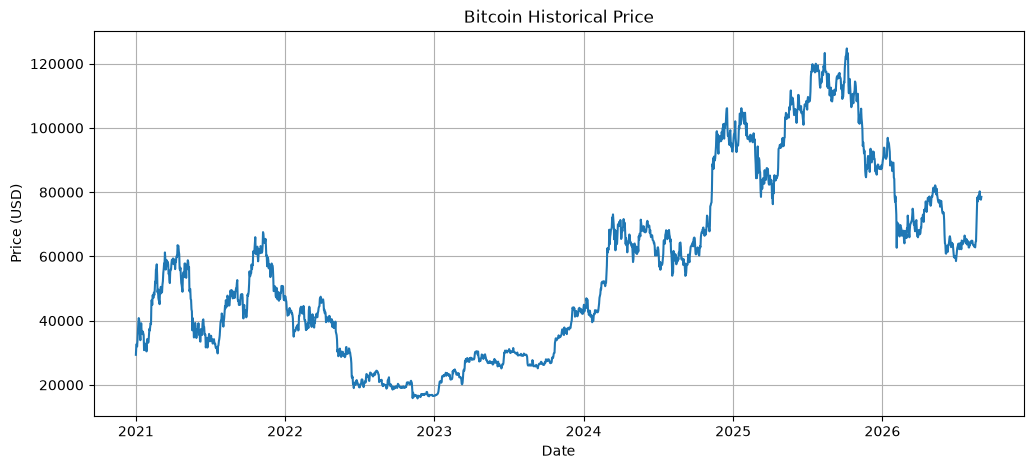

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["price"])
plt.title("Bitcoin Historical Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

# 5. Log Return Visualization
Visualizing daily Bitcoin log returns.

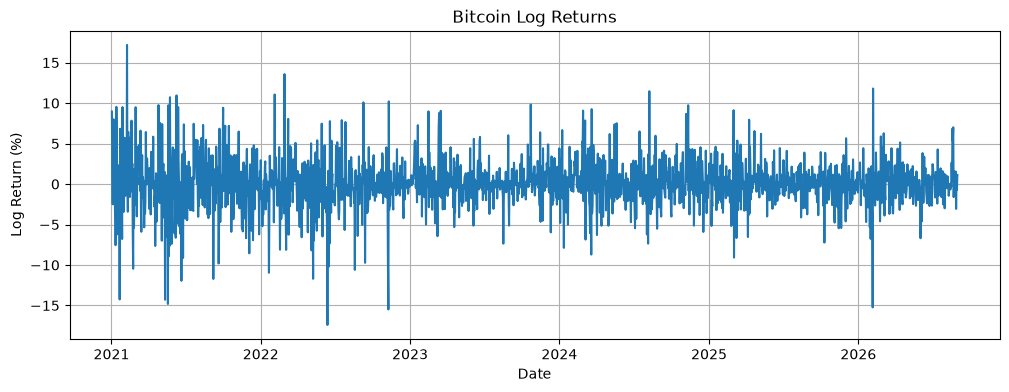

In [20]:
plt.figure(figsize=(12, 4))
plt.plot(returns)
plt.title("Bitcoin Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return (%)")
plt.grid(True)
plt.show()

# 6. Stationarity Test (ADF)
Testing whether Bitcoin prices and returns are stationary.

In [21]:
def check_stationarity(series, name):
    result = adfuller(series.dropna())

    print(f"--- ADF Test for {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"P-value: {result[1]:.4f}")

    if result[1] < 0.05:
        print("Result: Stationary\n")
    else:
        print("Result: Non-Stationary\n")

In [22]:
check_stationarity(df["price"], "Bitcoin Price")
check_stationarity(returns, "Bitcoin Log Returns")

--- ADF Test for Bitcoin Price ---
ADF Statistic: -1.2860
P-value: 0.6355
Result: Non-Stationary

--- ADF Test for Bitcoin Log Returns ---
ADF Statistic: -47.1506
P-value: 0.0000
Result: Stationary



C:\Users\r\AppData\Local\Temp\ipykernel_10272\3732504027.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna())
C:\Users\r\AppData\Local\Temp\ipykernel_10272\3732504027.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna())


# 7. ACF and PACF Analysis
Analyzing autocorrelation structures to support ARIMA model selection.

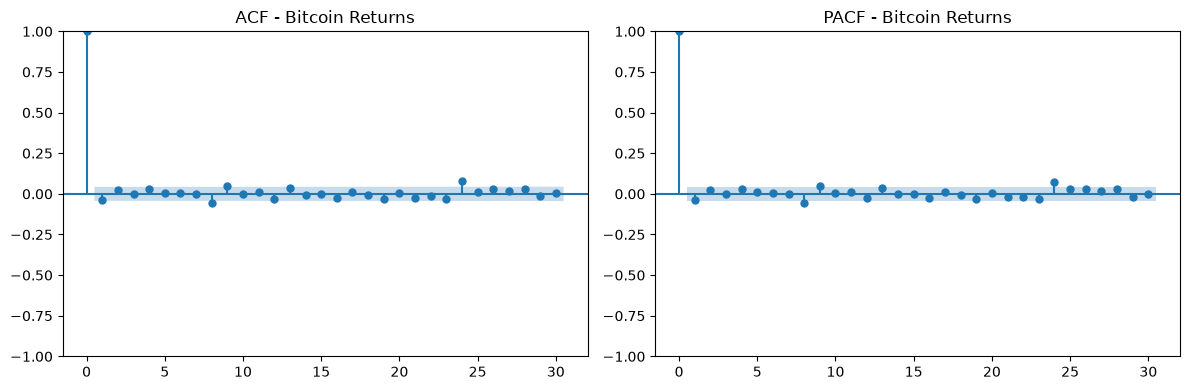

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(
    returns,
    lags=30,
    ax=axes[0],
    title="ACF - Bitcoin Returns"
)

plot_pacf(
    returns,
    lags=30,
    ax=axes[1],
    title="PACF - Bitcoin Returns"
)

plt.tight_layout()
plt.show()

# 8. ARIMA Model
Modeling return dynamics using ARIMA(1,0,1).

In [24]:
arima_order = (1, 0, 1)

arima_model = ARIMA(
    returns,
    order=arima_order
)

arima_results = arima_model.fit()

print(arima_results.summary())

c:\Users\r\Documents\GitHub\Financial-volatility-analysis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\r\Documents\GitHub\Financial-volatility-analysis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\r\Documents\GitHub\Financial-volatility-analysis\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 2068
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -5199.428
Date:                Mon, 14 Sep 2026   AIC                          10406.857
Time:                        17:47:17   BIC                          10429.394
Sample:                    01-02-2021   HQIC                         10415.118
                         - 08-31-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0475      0.065      0.729      0.466      -0.080       0.175
ar.L1         -0.5252      0.322     -1.629      0.103      -1.157       0.107
ma.L1          0.4890      0.329      1.484      0.1

# 9. Residual Analysis
Extracting residuals for volatility modeling.

In [25]:
residuals = arima_results.resid

residuals.head()

Date
2021-01-02    8.911546
2021-01-03    2.300492
2021-01-04   -2.639499
2021-01-05    6.032039
2021-01-06    8.198612
dtype: float64

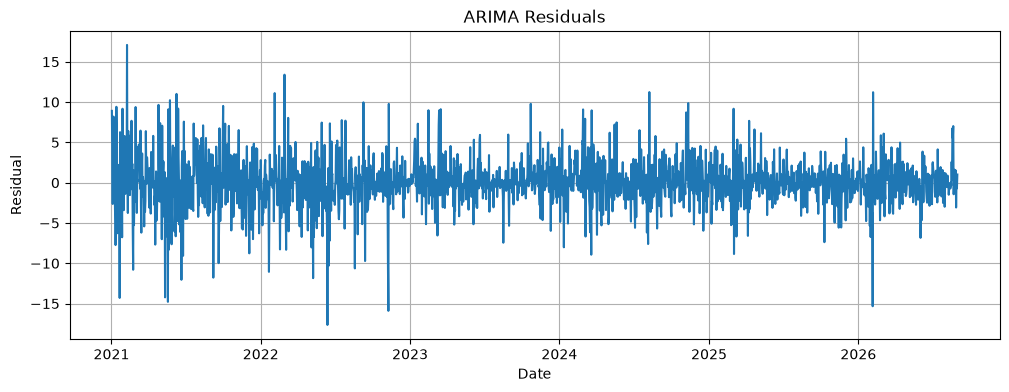

In [26]:
plt.figure(figsize=(12, 4))

plt.plot(residuals)

plt.title("ARIMA Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")

plt.grid(True)
plt.show()

# 10. GARCH Model
Modeling conditional volatility using GARCH(1,1).

In [27]:
garch_model = arch_model(
    residuals,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1
)

garch_results = garch_model.fit(
    disp="off"
)

print(garch_results.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5058.59
Distribution:                  Normal   AIC:                           10123.2
Method:            Maximum Likelihood   BIC:                           10140.1
                                        No. Observations:                 2068
Date:                Mon, Sep 14 2026   Df Residuals:                     2068
Time:                        17:48:39   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.2480      0.116      2.129  3.323e-02 [1.972e-0

# 11. Conditional Volatility
Estimating time-varying market risk.

In [28]:
df.loc[returns.index, "volatility"] = garch_results.conditional_volatility

df.tail()

,price,log_return,volatility
Date,,,
2026-08-27,80257.539062,0.015446,2.858817
2026-08-28,77830.289062,-0.030710,2.783449
2026-08-29,78245.812500,0.005325,2.814997
2026-08-30,77667.570312,-0.007418,2.711643
2026-08-31,78548.632812,0.011280,2.621226


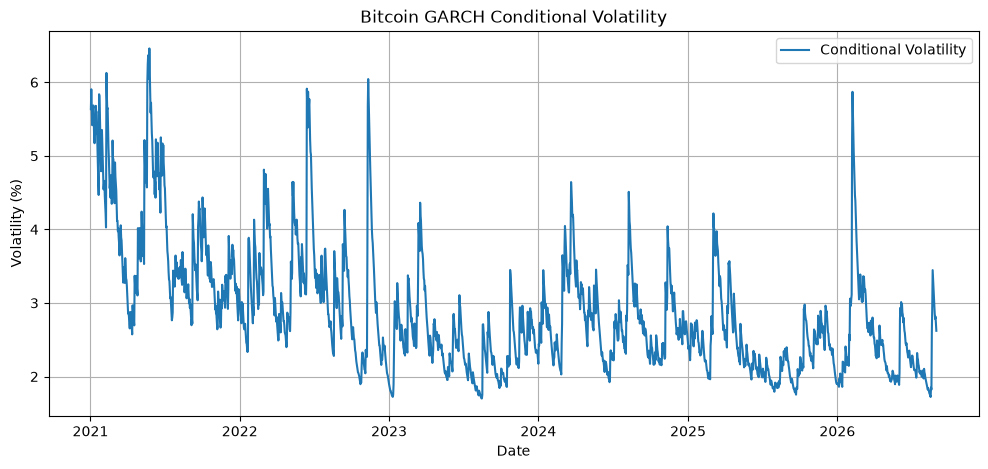

In [29]:
plt.figure(figsize=(12, 5))

plt.plot(
    df.index,
    df["volatility"],
    label="Conditional Volatility"
)

plt.title("Bitcoin GARCH Conditional Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")

plt.grid(True)
plt.legend()

plt.show()

# 12. Price vs Volatility
Comparing Bitcoin price movements with conditional volatility.

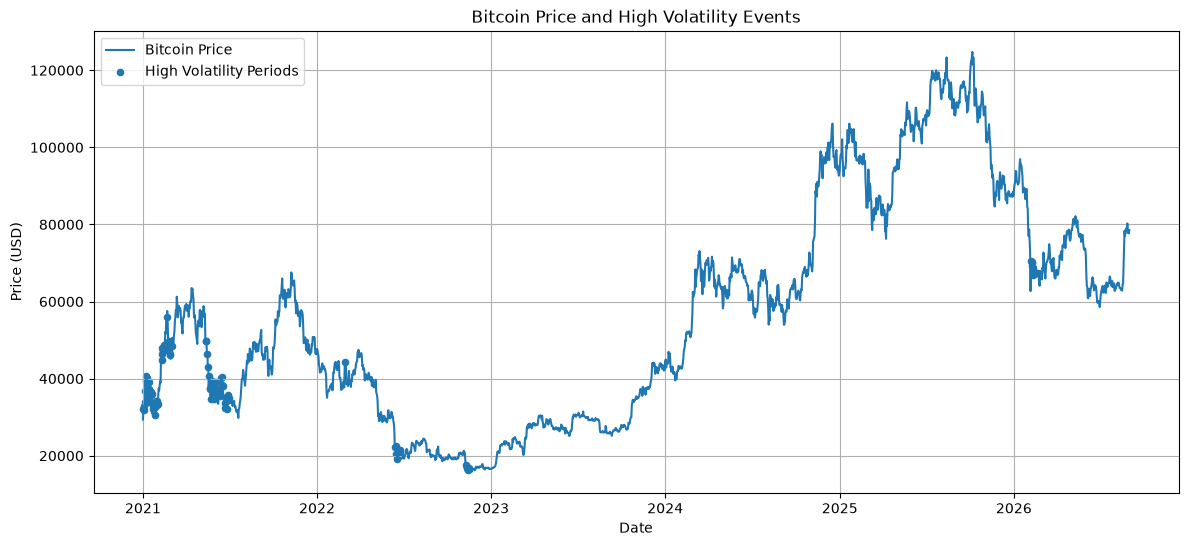

In [33]:
# 95 درصد بالاترین نوسانات
threshold = df["volatility"].quantile(0.95)

high_vol = df[
    df["volatility"] > threshold
]

plt.figure(figsize=(14, 6))

plt.plot(
    df.index,
    df["price"],
    label="Bitcoin Price"
)

plt.scatter(
    high_vol.index,
    high_vol["price"],
    s=20,
    label="High Volatility Periods"
)

plt.title(
    "Bitcoin Price and High Volatility Events"
)

plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()

plt.show()

# 13. Next-Day Forecast
Forecasting next-day return and volatility.

In [30]:
next_return_pred = arima_results.forecast(
    steps=1
).iloc[0]

garch_forecast = garch_results.forecast(
    horizon=1
)

next_vol_pred = np.sqrt(
    garch_forecast.variance.iloc[-1, 0]
)

print("--- Next Day Forecast ---")
print(f"Expected Return: {next_return_pred:.4f}%")
print(f"Expected Volatility: {next_vol_pred:.4f}%")

--- Next Day Forecast ---
Expected Return: -0.0253%
Expected Volatility: 2.5456%


# 14. Descriptive Statistics
Summary statistics of Bitcoin returns.

In [32]:
summary = pd.DataFrame({
    "Mean Return (%)": [returns.mean()],
    "Volatility Std (%)": [returns.std()],
    "Min Return (%)": [returns.min()],
    "Max Return (%)": [returns.max()],
    "Skewness": [returns.skew()],
    "Kurtosis": [returns.kurtosis()]
})

summary

,Mean Return (%),Volatility Std (%),Min Return (%),Max Return (%),Skewness,Kurtosis
0,0.047563,2.993478,-17.405255,17.182056,-0.136397,4.122793


# 15. Key Findings

## Main Findings

- Bitcoin prices were non-stationary.
- Log returns were stationary.
- ARIMA showed limited predictive power.
- GARCH successfully captured volatility dynamics.
- Volatility persistence was very high (α + β = 0.973).
- Forecasted next-day volatility was approximately 2.55%.
- Bitcoin returns exhibited fat tails and volatility clustering.

# 16. Conclusion
This project demonstrates how ARIMA and GARCH can be combined to model return dynamics and volatility in financial markets. The results suggest that Bitcoin returns are difficult to predict, while volatility exhibits strong persistence and clustering behavior.